# Linear Regression - Network Throughput Prediction

**Target: Data Throughput (Mbps)**

## Repository Setup

Clone the project repository and set the working directory to the project root for accessing the prepared datasets and storing the trained model.


In [24]:
!git clone https://github.com/MohamedAAbdullah1/NTI-Final-Project.git
%cd NTI-Final-Project

Cloning into 'NTI-Final-Project'...
remote: Enumerating objects: 98, done.
remote: Counting objects: 100% (98/98), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 98 (delta 40), reused 43 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (98/98), 3.25 MiB | 13.43 MiB/s, done.
Resolving deltas: 100% (40/40), done.
/content/NTI-Final-Project/NTI-Final-Project/NTI-Final-Project


## Environment Setup and Required Libraries

Import the libraries required for data analysis, visualization, preprocessing, model training, evaluation, and model persistence.


In [34]:
import numpy as np
import pandas as pd
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


## Dataset Loading and Train-Test Data Preparation

Load the processed dataset along with the predefined training and testing feature sets and target values used for model development.


In [4]:
df = pd.read_csv("../data/processed/processed_data.csv")

x_train = pd.read_csv("../data/processed/X_train.csv")
x_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

## Numerical and Categorical Feature Identification

Identify numerical and categorical features to apply the appropriate preprocessing technique to each feature type.


In [6]:
x_num = x_train.select_dtypes(include='number').columns
x_cat = x_train.select_dtypes(include=['object', 'string']).columns
print("Numerical features:")
print(list(x_num))

print("\nCategorical features:")
print(list(x_cat))

Numerical features:
['Latitude', 'Longitude', 'Signal Strength (dBm)', 'Latency (ms)']

Categorical features:
['Locality', 'Network Type']


## Data Preprocessing Pipeline

Build a preprocessing pipeline that standardizes numerical features and applies one-hot encoding to categorical features while keeping the transformations integrated with the model workflow.


In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), x_num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), x_cat)
    ]
)

## Data Preprocessing Pipeline

Build a preprocessing pipeline that standardizes numerical features and applies one-hot encoding to categorical features while keeping the transformations integrated with the model workflow.


In [20]:
lr_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

## Model Training

Train the Linear Regression pipeline using the prepared training dataset.


In [21]:
x_train

,Locality,Latitude,Longitude,Signal Strength (dBm),Latency (ms),Network Type
0,Pataliputra,25.605539,85.285651,-87.611830,164.101054,4G
1,Kidwaipuri,25.491973,85.086669,-90.089704,22.851745,5G
2,Danapur,25.684972,84.989785,-90.175391,139.812003,4G
3,Kankarbagh,25.569868,85.138714,-93.384826,113.904981,4G
4,Phulwari Sharif,25.626811,85.136823,-95.888704,71.291449,4G
...,...,...,...,...,...,...
13458,Patliputra Colony,25.625731,85.236979,-99.855504,14.347403,5G
13459,Boring Road,25.542265,85.136312,-103.143612,11.928246,5G
13460,Anandpuri,25.760196,85.106948,-86.819045,110.012450,3G
13461,Kankarbagh,25.639334,85.236360,-83.653550,158.589235,3G


In [22]:
x_test

,Locality,Latitude,Longitude,Signal Strength (dBm),Latency (ms),Network Type
0,Anisabad,25.726280,85.079655,-88.480745,17.376201,5G
1,Exhibition Road,25.463564,85.152798,-91.032814,67.273238,4G
2,Gandhi Maidan,25.487188,85.138136,-85.620351,73.451172,4G
3,Kankarbagh,25.690184,85.254868,-82.582479,190.053481,3G
4,Gandhi Maidan,25.500215,84.989757,-85.654623,62.809294,4G
...,...,...,...,...,...,...
3361,Exhibition Road,25.612153,85.209633,-81.761446,108.516717,3G
3362,Gardanibagh,25.498034,85.159263,-87.373974,158.987036,3G
3363,Patliputra Colony,25.745393,85.182098,-107.361245,22.863737,5G
3364,Anisabad,25.604416,85.193540,-83.358016,162.157226,3G


In [23]:
y_train

,Data Throughput (Mbps)
0,1.054622
1,27.746917
2,1.389367
3,1.905477
4,4.013216
...,...
13458,51.660849
13459,61.158540
13460,2.753941
13461,2.621240


In [24]:
y_test

,Data Throughput (Mbps)
0,59.288426
1,9.045216
2,5.414390
3,1.215062
4,3.782074
...,...
3361,2.142524
3362,1.468759
3363,11.040519
3364,2.375605


## Training and Test Set Predictions

Generate predictions for both the training and test datasets to evaluate model performance and compare its behavior on seen and unseen data.


In [25]:
lr_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Locality','Latitude','Longitude','Signal Strength (dBm)','Latency (ms)', 'Network Type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This 

In [27]:
y_pred_train = lr_pipeline.predict(x_train)

In [28]:
y_pred_test = lr_pipeline.predict(x_test)

## Linear Regression Performance Evaluation

Evaluate the model using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² on both training and test datasets.


In [30]:
test_mae = mean_absolute_error(y_test, y_pred_test)
test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred_test)

train_mae = mean_absolute_error(y_train, y_pred_train)
train_mse = mean_squared_error(y_train, y_pred_train)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_pred_train)

print("Training Performance")
print(f"MAE  : {train_mae:.4f}")
print(f"MSE  : {train_mse:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"R²   : {train_r2:.4f}")

print("\nTest Performance")
print(f"MAE  : {test_mae:.4f}")
print(f"MSE  : {test_mse:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R²   : {test_r2:.4f}")

Training Performance
MAE  : 6.6466
MSE  : 169.6143
RMSE : 13.0236
R²   : 0.7421

Test Performance
MAE  : 6.8287
MSE  : 177.3976
RMSE : 13.3191
R²   : 0.7363


## Linear Regression Coefficient Analysis

Extract and analyze the model coefficients to identify the features with the largest influence on the Linear Regression model in terms of coefficient magnitude.


In [32]:
feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()
coefficients = lr_pipeline.named_steps['model'].coef_.flatten()

coefficient_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coefficient_df['Absolute Coefficient'] = coefficient_df['Coefficient'].abs()

coefficient_df = coefficient_df.sort_values(
    'Absolute Coefficient',
    ascending=False
)

print(coefficient_df)

                            Feature  Coefficient  Absolute Coefficient
26             cat__Network Type_5G    31.864442             31.864442
24             cat__Network Type_3G   -16.346318             16.346318
25             cat__Network Type_4G   -15.518124             15.518124
3                 num__Latency (ms)    -1.916421              1.916421
23          cat__Locality_S.K. Puri    -1.033899              1.033899
16         cat__Locality_Kankarbagh     0.761003              0.761003
4           cat__Locality_Anandpuri     0.729108              0.729108
20  cat__Locality_Patliputra Colony    -0.709633              0.709633
14      cat__Locality_Gandhi Maidan    -0.654437              0.654437
13        cat__Locality_Fraser Road    -0.587613              0.587613
12    cat__Locality_Exhibition Road     0.575071              0.575071
5            cat__Locality_Anisabad     0.485004              0.485004
9   cat__Locality_Boring Canal Road     0.449620              0.449620
15    

## Top Feature Coefficients Visualization

Visualize the most influential Linear Regression coefficients to provide a clearer interpretation of the model's learned relationships with the input features.


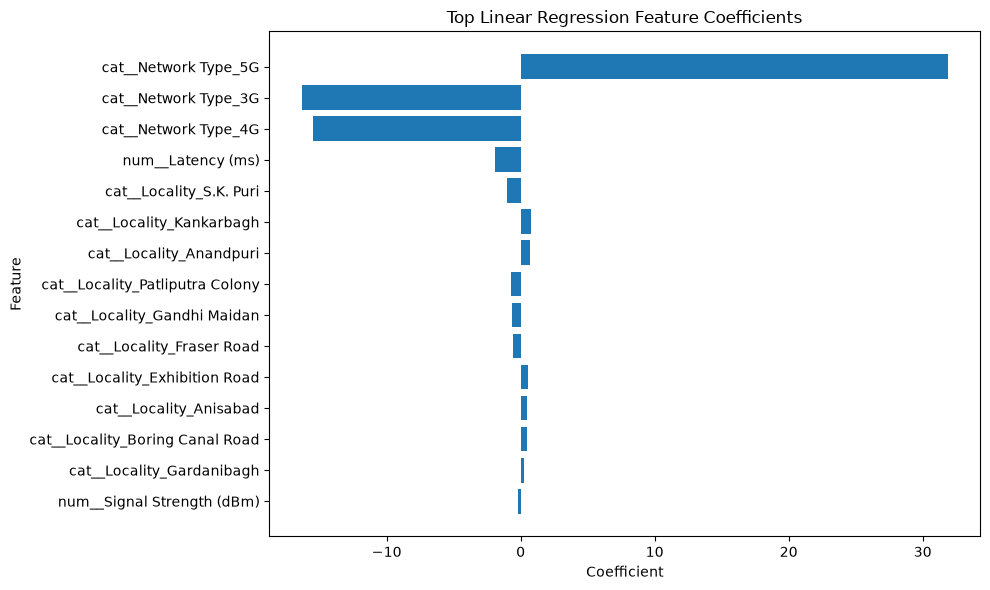

In [35]:
top_features = coefficient_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'][::-1],
    top_features['Coefficient'][::-1]
)

plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.title('Top Linear Regression Feature Coefficients')

plt.tight_layout()
plt.show()

## Saving the Trained Model

Save the complete Linear Regression pipeline, including preprocessing and the trained model, as a reusable Joblib file for later inference and deployment.


In [38]:
joblib.dump(
    lr_pipeline,
    '../models/linear_regression.joblib'
)

print("Linear Regression pipeline saved successfully.")

Linear Regression pipeline saved successfully.


## Saved Pipeline Verification

Reload the saved Linear Regression pipeline to verify that the trained model was successfully persisted and can be restored for future predictions.


In [40]:
loaded_model = joblib.load('../models/linear_regression.joblib')

print("Linear Regression pipeline loaded successfully.")

Linear Regression pipeline loaded successfully.
